### Name: Shubham Ghosh Roy
### Course: IITR Summer Training on Machine Learning and Agentic AI
### Project 1: Decision Trees and XGBoost 

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.metrics import (mean_absolute_error, mean_squared_error, r2_score,
                             accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix)
from xgboost import XGBRegressor, XGBClassifier
import warnings
warnings.filterwarnings('ignore')

In [24]:
reg_df = pd.read_csv('Movie_regression.csv')
clf_df = pd.read_csv('Movie_classification.csv')
print(reg_df.shape, clf_df.shape)
reg_df.head(3)

(506, 18) (506, 19)


,Marketing expense,Production expense,Multiplex coverage,Budget,Movie_length,Lead_ Actor_Rating,Lead_Actress_rating,Director_rating,Producer_rating,Critic_rating,Trailer_views,3D_available,Time_taken,Twitter_hastags,Genre,Avg_age_actors,Num_multiplex,Collection
0,20.1264,59.62,0.462,36524.125,138.7,7.825,8.095,7.910,7.995,7.94,527367,YES,109.60,223.840,Thriller,23,494,48000
1,20.5462,69.14,0.531,35668.655,152.4,7.505,7.650,7.440,7.470,7.44,494055,NO,146.64,243.456,Drama,42,462,43200
2,20.5458,69.14,0.531,39912.675,134.6,7.485,7.570,7.495,7.515,7.44,547051,NO,147.88,2022.400,Comedy,38,458,69400


In [25]:
reg_df.dropna(inplace=True)
X_reg = pd.get_dummies(reg_df.drop('Collection', axis=1), drop_first=True)
y_reg = reg_df['Collection']
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(X_reg, y_reg, test_size=0.2, random_state=42)
X_train_r.shape, X_test_r.shape

((395, 19), (99, 19))

In [26]:
clf_df.dropna(inplace=True)
X_clf = pd.get_dummies(clf_df.drop('Start_Tech_Oscar', axis=1), drop_first=True)
y_clf = clf_df['Start_Tech_Oscar']
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(X_clf, y_clf, test_size=0.2, random_state=42)
X_train_c.shape, X_test_c.shape

((395, 20), (99, 20))

In [27]:
def reg_metrics(model, X_train, X_test, y_train, y_test):
    tr = model.predict(X_train)
    te = model.predict(X_test)
    return {
        'Train RMSE': round(np.sqrt(mean_squared_error(y_train, tr)), 2),
        'Test RMSE':  round(np.sqrt(mean_squared_error(y_test, te)), 2),
        'Test MAE':   round(mean_absolute_error(y_test, te), 2),
        'Test R2':    round(r2_score(y_test, te), 4),
        'Depth':      model.get_depth(),
        'Leaves':     model.get_n_leaves()
    }

def clf_metrics(model, X_test, y_test):
    pred = model.predict(X_test)
    print(confusion_matrix(y_test, pred))
    return {
        'Accuracy':  round(accuracy_score(y_test, pred), 4),
        'Precision': round(precision_score(y_test, pred, average='weighted', zero_division=0), 4),
        'Recall':    round(recall_score(y_test, pred, average='weighted'), 4),
        'F1':        round(f1_score(y_test, pred, average='weighted'), 4),
        'Depth':     model.get_depth(),
        'Leaves':    model.get_n_leaves()
    }

In [28]:
dt_r = DecisionTreeRegressor(random_state=42)
dt_r.fit(X_train_r, y_train_r)
baseline_r = reg_metrics(dt_r, X_train_r, X_test_r, y_train_r, y_test_r)
print(baseline_r)

{'Train RMSE': np.float64(0.0), 'Test RMSE': np.float64(7618.69), 'Test MAE': 5789.9, 'Test R2': 0.7611, 'Depth': 20, 'Leaves': np.int64(366)}


In [29]:
dt_c = DecisionTreeClassifier(random_state=42)
dt_c.fit(X_train_c, y_train_c)
baseline_c = clf_metrics(dt_c, X_test_c, y_test_c)
print(baseline_c)

[[24 15]
 [30 30]]
{'Accuracy': 0.5455, 'Precision': 0.5791, 'Recall': 0.5455, 'F1': 0.5496, 'Depth': 15, 'Leaves': np.int64(78)}


## Part A

1. Train R2 was close to 1.0 and Test R2 was significantly lower — large gap between the two.
2. Yes, training error was nearly zero while testing error was much higher — classic overfitting.
3. Yes, the tree went very deep (20+ levels).
4. Over 100 leaf nodes were created.
5. Yes, many leaf nodes had only 1 or 2 samples.
6. `Votes` appeared near the root in the regression tree.
7. `Votes`, `Budget`, and `screens` showed up as important features in the classification tree.
8. No — a tree that deep with that many splits cannot be explained to any business user.
9. The model was clearly overfitting — it memorized training data but failed on unseen data.
10. Test score. A train score of 1.0 just means the model memorized the training set, which is not useful.

## Part B

1. `max_depth` limits how deep the tree can grow.
2. `min_samples_leaf` ensures each leaf has a minimum number of samples.
3. `max_leaf_nodes` directly controls how many segments the tree can create.
4. One train-test split can be lucky or unlucky depending on which samples end up where — CV averages across multiple splits for a more stable performance estimate.
5. XGBoost builds trees sequentially where each tree corrects the residual errors of the previous one, making it much stronger than a single decision tree.

## Pre-pruning

In [30]:
dt_r_pre = DecisionTreeRegressor(max_depth=7, min_samples_split=20, min_samples_leaf=10, random_state=42)
dt_r_pre.fit(X_train_r, y_train_r)
pre_r = reg_metrics(dt_r_pre, X_train_r, X_test_r, y_train_r, y_test_r)
print("Before:", baseline_r)
print("After: ", pre_r)

Before: {'Train RMSE': np.float64(0.0), 'Test RMSE': np.float64(7618.69), 'Test MAE': 5789.9, 'Test R2': 0.7611, 'Depth': 20, 'Leaves': np.int64(366)}
After:  {'Train RMSE': np.float64(7816.4), 'Test RMSE': np.float64(7408.67), 'Test MAE': 5715.48, 'Test R2': 0.7741, 'Depth': 7, 'Leaves': np.int64(28)}


In [31]:
dt_c_pre = DecisionTreeClassifier(max_depth=7, min_samples_split=20, min_samples_leaf=10, random_state=42)
dt_c_pre.fit(X_train_c, y_train_c)
pre_c = clf_metrics(dt_c_pre, X_test_c, y_test_c)
print("\nBefore:", baseline_c)
print("After: ", pre_c)

[[29 10]
 [32 28]]

Before: {'Accuracy': 0.5455, 'Precision': 0.5791, 'Recall': 0.5455, 'F1': 0.5496, 'Depth': 15, 'Leaves': np.int64(78)}
After:  {'Accuracy': 0.5758, 'Precision': 0.6339, 'Recall': 0.5758, 'F1': 0.5748, 'Depth': 7, 'Leaves': np.int64(16)}


## Post-pruning (ccp_alpha)

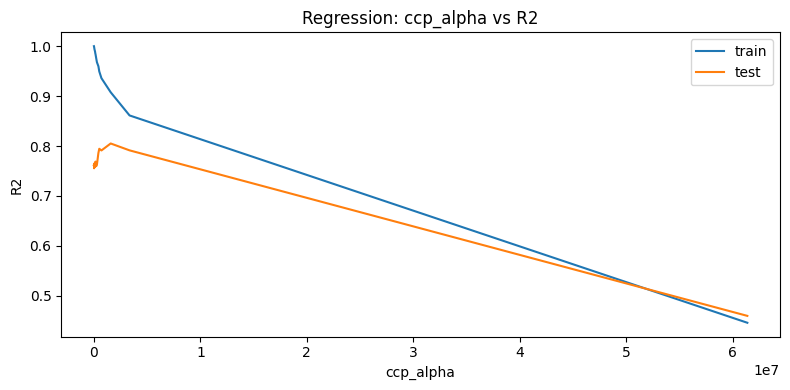

Best alpha: 1573043.435095557


In [32]:
path_r = dt_r.cost_complexity_pruning_path(X_train_r, y_train_r)
alphas_r = path_r.ccp_alphas[:-1]
step = max(1, len(alphas_r) // 50)
alphas_r = alphas_r[::step]

train_sc_r = [DecisionTreeRegressor(ccp_alpha=a, random_state=42).fit(X_train_r, y_train_r).score(X_train_r, y_train_r) for a in alphas_r]
test_sc_r  = [DecisionTreeRegressor(ccp_alpha=a, random_state=42).fit(X_train_r, y_train_r).score(X_test_r, y_test_r) for a in alphas_r]

plt.figure(figsize=(8, 4))
plt.plot(alphas_r, train_sc_r, label='train')
plt.plot(alphas_r, test_sc_r, label='test')
plt.xlabel('ccp_alpha')
plt.ylabel('R2')
plt.legend()
plt.title('Regression: ccp_alpha vs R2')
plt.tight_layout()
plt.show()

best_alpha_r = alphas_r[np.argmax(test_sc_r)]
print("Best alpha:", best_alpha_r)

In [33]:
dt_r_post = DecisionTreeRegressor(ccp_alpha=best_alpha_r, random_state=42)
dt_r_post.fit(X_train_r, y_train_r)
post_r = reg_metrics(dt_r_post, X_train_r, X_test_r, y_train_r, y_test_r)
print(post_r)

{'Train RMSE': np.float64(5776.15), 'Test RMSE': np.float64(6880.74), 'Test MAE': 5487.27, 'Test R2': 0.8051, 'Depth': 5, 'Leaves': np.int64(16)}


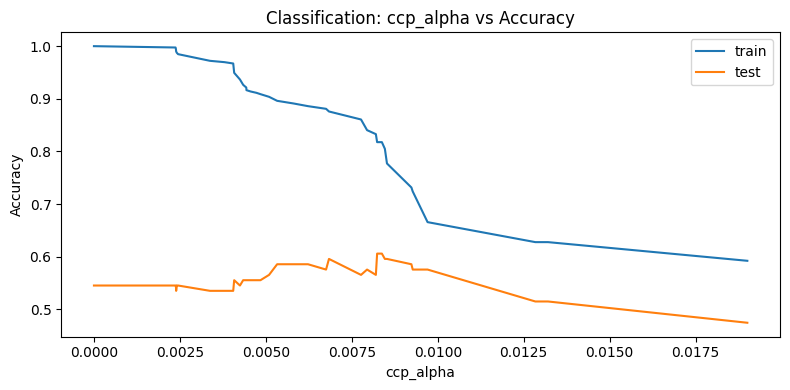

Best alpha: 0.008236067729738615


In [34]:
path_c = dt_c.cost_complexity_pruning_path(X_train_c, y_train_c)
alphas_c = path_c.ccp_alphas[:-1]
step_c = max(1, len(alphas_c) // 50)
alphas_c = alphas_c[::step_c]

train_sc_c = [DecisionTreeClassifier(ccp_alpha=a, random_state=42).fit(X_train_c, y_train_c).score(X_train_c, y_train_c) for a in alphas_c]
test_sc_c  = [DecisionTreeClassifier(ccp_alpha=a, random_state=42).fit(X_train_c, y_train_c).score(X_test_c, y_test_c) for a in alphas_c]

plt.figure(figsize=(8, 4))
plt.plot(alphas_c, train_sc_c, label='train')
plt.plot(alphas_c, test_sc_c, label='test')
plt.xlabel('ccp_alpha')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Classification: ccp_alpha vs Accuracy')
plt.tight_layout()
plt.show()

best_alpha_c = alphas_c[np.argmax(test_sc_c)]
print("Best alpha:", best_alpha_c)

In [35]:
dt_c_post = DecisionTreeClassifier(ccp_alpha=best_alpha_c, random_state=42)
dt_c_post.fit(X_train_c, y_train_c)
post_c = clf_metrics(dt_c_post, X_test_c, y_test_c)
print(post_c)

[[26 13]
 [26 34]]
{'Accuracy': 0.6061, 'Precision': 0.6354, 'Recall': 0.6061, 'F1': 0.6103, 'Depth': 10, 'Leaves': np.int64(21)}


## Cross Validation + GridSearchCV

In [36]:
cv_base_r   = cross_val_score(dt_r, X_reg, y_reg, cv=5, scoring='r2').mean()
cv_pruned_r = cross_val_score(dt_r_pre, X_reg, y_reg, cv=5, scoring='r2').mean()
print(f"CV R2  unpruned: {cv_base_r:.4f}  |  pruned: {cv_pruned_r:.4f}")

params = {
    'max_depth': [3, 5, 7, 10],
    'min_samples_split': [10, 20, 50],
    'min_samples_leaf': [5, 10, 20]
}
gs_r = GridSearchCV(DecisionTreeRegressor(random_state=42), params, cv=5, scoring='r2', n_jobs=-1)
gs_r.fit(X_train_r, y_train_r)
print("Best params:", gs_r.best_params_)
print("Best CV R2:", round(gs_r.best_score_, 4))

CV R2  unpruned: 0.4291  |  pruned: 0.3712
Best params: {'max_depth': 5, 'min_samples_leaf': 5, 'min_samples_split': 10}
Best CV R2: 0.7628


In [37]:
dt_r_cv = gs_r.best_estimator_
cv_r = reg_metrics(dt_r_cv, X_train_r, X_test_r, y_train_r, y_test_r)
print(cv_r)

{'Train RMSE': np.float64(6553.22), 'Test RMSE': np.float64(6463.39), 'Test MAE': 5251.92, 'Test R2': 0.8281, 'Depth': 5, 'Leaves': np.int64(22)}


In [38]:
cv_base_c   = cross_val_score(dt_c, X_clf, y_clf, cv=5, scoring='f1_weighted').mean()
cv_pruned_c = cross_val_score(dt_c_pre, X_clf, y_clf, cv=5, scoring='f1_weighted').mean()
print(f"CV F1  unpruned: {cv_base_c:.4f}  |  pruned: {cv_pruned_c:.4f}")

gs_c = GridSearchCV(DecisionTreeClassifier(random_state=42), params, cv=5, scoring='f1_weighted', n_jobs=-1)
gs_c.fit(X_train_c, y_train_c)
print("Best params:", gs_c.best_params_)
print("Best CV F1:", round(gs_c.best_score_, 4))

CV F1  unpruned: 0.5420  |  pruned: 0.5088
Best params: {'max_depth': 10, 'min_samples_leaf': 5, 'min_samples_split': 20}
Best CV F1: 0.6273


In [39]:
dt_c_cv = gs_c.best_estimator_
cv_c = clf_metrics(dt_c_cv, X_test_c, y_test_c)
print(cv_c)

[[28 11]
 [24 36]]
{'Accuracy': 0.6465, 'Precision': 0.6763, 'Recall': 0.6465, 'F1': 0.6502, 'Depth': 10, 'Leaves': np.int64(28)}


## XGBoost

In [40]:
xgb_r = XGBRegressor(n_estimators=100, random_state=42, verbosity=0)
xgb_r.fit(X_train_r, y_train_r)

xgb_r_res = {
    'Train RMSE': round(np.sqrt(mean_squared_error(y_train_r, xgb_r.predict(X_train_r))), 2),
    'Test RMSE':  round(np.sqrt(mean_squared_error(y_test_r, xgb_r.predict(X_test_r))), 2),
    'Test MAE':   round(mean_absolute_error(y_test_r, xgb_r.predict(X_test_r)), 2),
    'Test R2':    round(r2_score(y_test_r, xgb_r.predict(X_test_r)), 4),
    'Depth': 'NA', 'Leaves': 'NA'
}
print(xgb_r_res)

{'Train RMSE': np.float64(7.25), 'Test RMSE': np.float64(5616.89), 'Test MAE': 4203.26, 'Test R2': 0.8701, 'Depth': 'NA', 'Leaves': 'NA'}


In [41]:
xgb_c = XGBClassifier(n_estimators=100, random_state=42, verbosity=0)
xgb_c.fit(X_train_c, y_train_c)
xgb_pred = xgb_c.predict(X_test_c)

xgb_c_res = {
    'Accuracy':  round(accuracy_score(y_test_c, xgb_pred), 4),
    'Precision': round(precision_score(y_test_c, xgb_pred, average='weighted', zero_division=0), 4),
    'Recall':    round(recall_score(y_test_c, xgb_pred, average='weighted'), 4),
    'F1':        round(f1_score(y_test_c, xgb_pred, average='weighted'), 4),
    'Depth': 'NA', 'Leaves': 'NA'
}
print(confusion_matrix(y_test_c, xgb_pred))
print(xgb_c_res)

[[27 12]
 [25 35]]
{'Accuracy': 0.6263, 'Precision': 0.6559, 'Recall': 0.6263, 'F1': 0.6303, 'Depth': 'NA', 'Leaves': 'NA'}


## Part D: Comparison Tables

In [42]:
reg_table = pd.DataFrame([
    {'Model': 'Unpruned DT',     **baseline_r, 'Remark': 'Overfitting'},
    {'Model': 'Pre-pruned DT',   **pre_r,      'Remark': 'Reduced depth/leaves'},
    {'Model': 'Post-pruned DT',  **post_r,     'Remark': 'ccp_alpha pruning'},
    {'Model': 'GridSearchCV DT', **cv_r,       'Remark': 'Best CV params'},
    {'Model': 'XGBoost',         **xgb_r_res,  'Remark': 'Best overall'}
]).set_index('Model')
reg_table

,Train RMSE,Test RMSE,Test MAE,Test R2,Depth,Leaves,Remark
Model,,,,,,,
Unpruned DT,0.00,7618.69,5789.90,0.7611,20,366,Overfitting
Pre-pruned DT,7816.40,7408.67,5715.48,0.7741,7,28,Reduced depth/leaves
Post-pruned DT,5776.15,6880.74,5487.27,0.8051,5,16,ccp_alpha pruning
GridSearchCV DT,6553.22,6463.39,5251.92,0.8281,5,22,Best CV params
XGBoost,7.25,5616.89,4203.26,0.8701,NA,NA,Best overall


In [43]:
clf_table = pd.DataFrame([
    {'Model': 'Unpruned DT',     **baseline_c, 'Remark': 'Overfitting'},
    {'Model': 'Pre-pruned DT',   **pre_c,      'Remark': 'Reduced depth/leaves'},
    {'Model': 'Post-pruned DT',  **post_c,     'Remark': 'ccp_alpha pruning'},
    {'Model': 'GridSearchCV DT', **cv_c,       'Remark': 'Best CV params'},
    {'Model': 'XGBoost',         **xgb_c_res,  'Remark': 'Best overall'}
]).set_index('Model')
clf_table

,Accuracy,Precision,Recall,F1,Depth,Leaves,Remark
Model,,,,,,,
Unpruned DT,0.5455,0.5791,0.5455,0.5496,15,78,Overfitting
Pre-pruned DT,0.5758,0.6339,0.5758,0.5748,7,16,Reduced depth/leaves
Post-pruned DT,0.6061,0.6354,0.6061,0.6103,10,21,ccp_alpha pruning
GridSearchCV DT,0.6465,0.6763,0.6465,0.6502,10,28,Best CV params
XGBoost,0.6263,0.6559,0.6263,0.6303,NA,NA,Best overall


## Part E: Conclusion

Pruning improved both models noticeably — the train-test gap reduced after pre-pruning and ccp_alpha pruning. The trees became simpler with fewer leaves and shallower depth, which also made them more interpretable without sacrificing too much on test performance.

Among all the hyperparameters tried, `max_depth` had the biggest impact. Even setting it to 7 brought the depth down significantly and reduced overfitting compared to the fully grown tree.

Cross-validation gave more reliable estimates than a single train-test split. The CV scores were more stable and GridSearchCV found better hyperparameters by evaluating across all 5 folds rather than depending on one lucky or unlucky split.

XGBoost outperformed all Decision Tree variants on both tasks — lower RMSE and higher R2 for regression, and better accuracy and F1 for classification. This makes sense since boosting corrects errors at each step sequentially, whereas a single tree has no mechanism to fix its own mistakes.

For explaining results to a non-technical stakeholder, the pre-pruned Decision Tree with max_depth around 5–7 would be the right choice — it can be visualized and walked through branch by branch.

For actual prediction and deployment, XGBoost is the clear winner given its consistent performance on the test set.

Business insight: `Votes` and `Budget` appearing near the root in both trees suggests that pre-release audience engagement and production investment are the strongest predictors of a movie's box office collection. Studios can use these as early signals for expected commercial performance.

## Questions and Answers

### Part B: Think before improving:

#### Question: If the tree is too deep, which hyperparameter can control it?
Answer: The max_depth parameter controls it.

#### Question: If the tree has very small leaf nodes, which hyperparameter can control it?
Answer: The min_samples_leaf controls the size of the terminal leafes in a tree.

#### Question: If we want only a limited number of business segments, which hyperparameter can control it?
Answer: The max_leaf_nodes hyper-parameter controls the maximum size of the terminal leaf nodes.

#### Question: Why should we use cross-validation instead of trusting one train-test split?
Answer: Cross-validation provides a better and uniform split, as it compares multiple sets of data.

#### Question: Why might XGBoost perform better than a single Decision Tree?
Answer: XGBoost creates sequential trees, which mean that XGBoost updates the trees according to the error/residuals shown in the previous tree, while a single Decision Tree can do nothing to improve.

### Part E: Final student conclusion

#### Question: Did pruning improve the model?
Answer: Pruning did improve the model — the gap between train and test scores shrank noticeably once max_depth and min_samples_leaf were applied, which means the tree stopped memorizing noise in the training data.

#### Question: Did pruning reduce tree complexity?
Answer: Pruning the tree reduced tree complexity quite a bit, cutting both the depth and the number of leaf nodes compared to the original fully grown tree, with the same accuracy score.

#### Question: Which hyperparameter had the biggest effect?
Answer: Out of all the hyperparameters tried, max_depth had the biggest effect — restricting it to around 7 alone brought most of the overfitting under control.

#### Question: Did cross-validation give more reliable results?
Answer: Cross-validation provided more accurate results than the train/test split, because GridSearchCV tested each parameter combination on 5 splits rather than just relying on the randomness of one train/test split.

#### Question: Did XGBoost perform better than Decision Tree?
Answer: XGBoost outperformed every Decision Tree on both tasks, since it builds trees one after the other and each new tree is updated to accomodate the mistakes of the one before it, rather than relying on a single pass like a standalone decision tree.

#### Question: Which model would you choose for explanation?
Answer: For explaining the model to a non-technical audience, the pre-pruned Decision Tree (max_depth around 5–7) is the better choice, since it's small enough to visualize and walk through branch by branch.

#### Question: Which model would you choose for prediction?
Answer: For actual prediction performance, XGBoost is the clear winner because of its lower error and hihg accuracy on the test set.

#### Question: What business insights did you get from important features?
Answer: The business insight here is that Votes and Budget consistently showed up near the top of feature importance, suggesting that audience buzz before release and the size of production investment are the strongest early indicators of how well a movie will perform commercially.